<a href="https://colab.research.google.com/github/sats505/Celebal_DS_assignments/blob/main/Week6_Shatakshi_Upadhyay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install -q torch torchvision matplotlib numpy kaggle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cpu


In [32]:
!pip install -q --upgrade kaggle

# Remove old data first
!rm -rf data/mnist mnist-dataset.zip

# Download and unzip
!kaggle datasets download -d awsaf49/mnist-dataset
!unzip -q mnist-dataset.zip -d data/

# Check the folder structure
print("Checking folder structure...")
!ls data/mnist_png/

Dataset URL: https://www.kaggle.com/datasets/awsaf49/mnist-dataset
License(s): unknown
100% 28.6M/28.6M [00:00<00:00, 61.5MB/s]

replace data/mnist_png/testing/0/10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
Checking folder structure...
testing  training


In [33]:
# Images are in folders: data/mnist_png/training/0/, data/mnist_png/training/1/, etc.
# datasets.ImageFolder reads this structure automatically
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale if needed
    transforms.ToTensor(),  # Convert to tensor and scale [0,1]
])

# Load training data from folders
train_data = datasets.ImageFolder('data/mnist_png/training', transform=transform)
test_data = datasets.ImageFolder('data/mnist_png/testing', transform=transform)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Classes: {train_data.classes}")
# Split 20% of training for validation
# This helps me check if the model is overfitting
valid_size = 0.2
batch_size = 128

train_len = len(train_data)
indices = list(range(train_len))
np.random.shuffle(indices)
split = int(np.floor(valid_size * train_len))
train_idx, valid_idx = indices[split:], indices[:split]

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=SubsetRandomSampler(train_idx))
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=SubsetRandomSampler(valid_idx))
test_loader = DataLoader(test_data, batch_size=batch_size)

print(f"Train: {len(train_idx)}, Valid: {len(valid_idx)}, Test: {len(test_data)}")


Training samples: 60000
Test samples: 10000
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train: 48000, Valid: 12000, Test: 10000


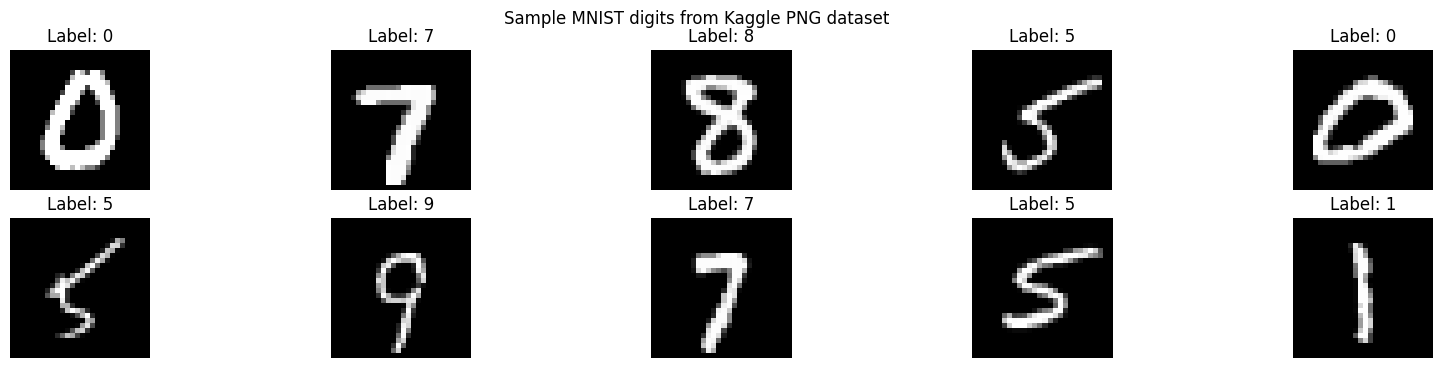

In [34]:
# Always good to visualize what you're working with
images, labels = next(iter(train_loader))

plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'Label: {labels[i].item()}')
    plt.axis('off')
plt.suptitle('Sample MNIST digits from Kaggle PNG dataset')
plt.show()

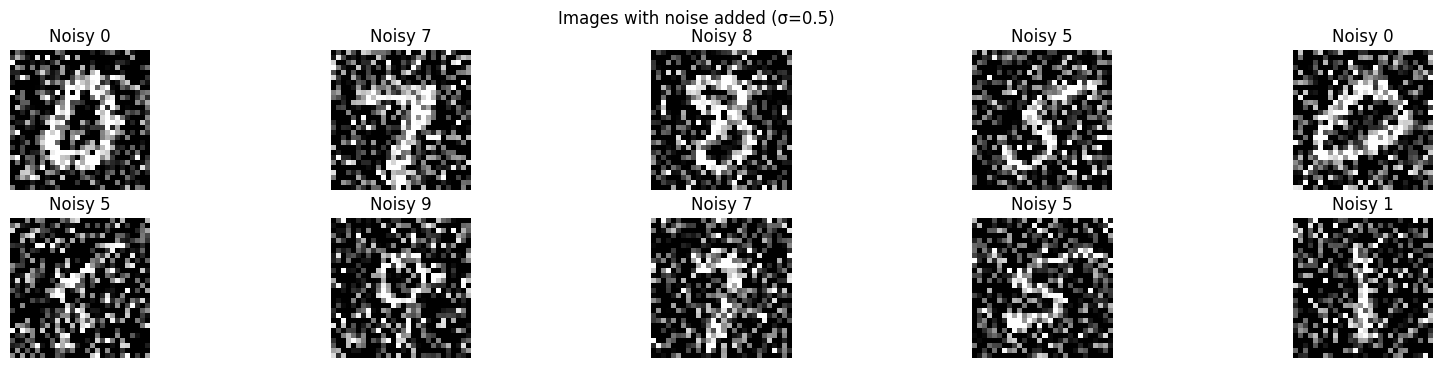

In [35]:
def add_noise(images, noise_factor=0.5):
    """
    Add Gaussian noise to images.
    noise_factor=0.5 means the noise standard deviation is 0.5
    I chose 0.5 because it makes digits blurry but still recognizable
    Too much noise (0.7+) and even humans can't read them
    Too little (0.3) and the model doesn't learn much
    """
    noise = noise_factor * torch.randn_like(images)
    return torch.clamp(images + noise, 0., 1.)

# Show what noise looks like
noisy = add_noise(images, noise_factor=0.5)

plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(noisy[i][0], cmap='gray')
    plt.title(f'Noisy {labels[i].item()}')
    plt.axis('off')
plt.suptitle('Images with noise added (σ=0.5)')
plt.show()

In [36]:
# Model 1: FFNN Autoencoder - Flattens image, compresses, rebuilds
# The 32 number bottleneck forces the model to learn the most important features
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim=32):
        super(F_Auto_MNIST, self).__init__()
        self.encoder = nn.Linear(784, en_dim)
        self.decoder = nn.Linear(en_dim, 784)

    def forward(self, x):
        x = F.relu(self.encoder(x))
        x = F.sigmoid(self.decoder(x))
        return x

# Model 2: Transpose CNN Autoencoder
# CNNs are better for images because they preserve spatial relationships
class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST, self).__init__()
        # Encoder
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Decoder (transpose convolution - expands back to full size)
        self.de_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.de_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.relu(self.de_conv1(x))
        x = F.sigmoid(self.de_conv2(x))
        return x

# Model 3: Upsampled CNN Autoencoder (no checkerboard artifacts)
# The GitHub reference warned that transpose convolutions can create checkerboard patterns
# This version uses upsampling + convolution to avoid that
class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST, self).__init__()
        # Encoder
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Decoder (upsampling + conv)
        self.de_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.de_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(torch.relu(self.en_conv1(x)))
        x = self.pool(torch.relu(self.en_conv2(x)))
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.relu(self.de_conv1(x))
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.sigmoid(self.de_conv2(x))
        return x


# Initialize models
model_ffnn = F_Auto_MNIST(32).to(device)
model_transpose = Tran_conv_Auto_MNIST().to(device)
model_upsampled = upsamp_conv_Auto_MNIST().to(device)

print("All models initialized!")

All models initialized!


In [37]:
def train_model(model, model_type='ffnn', epochs=20, lr=0.001):
    """
    Train autoencoder for denoising.

    Key difference from regular autoencoder:
    - Input: NOISY images
    - Target: CLEAN images
    - The model learns to remove noise!

    I'm using MSE loss because we're comparing pixel values
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    is_ffnn = (model_type == 'ffnn')
    train_losses, valid_losses = [], []
    best_loss = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            noisy = add_noise(images, noise_factor=0.5)

            if is_ffnn:
                noisy = noisy.view(noisy.size(0), -1)
                clean = images.view(images.size(0), -1)
            else:
                clean = images

            optimizer.zero_grad()
            output = model(noisy)
            loss = criterion(output, clean)  # Compare with CLEAN image
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for images, _ in valid_loader:
                images = images.to(device)
                noisy = add_noise(images, noise_factor=0.5)

                if is_ffnn:
                    noisy = noisy.view(noisy.size(0), -1)
                    clean = images.view(images.size(0), -1)
                else:
                    clean = images

                output = model(noisy)
                loss = criterion(output, clean)
                valid_loss += loss.item()

        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), f'best_{model_type}.pth')

        print(f"Epoch {epoch+1:2d}/{epochs} | Train: {train_loss:.6f} | Valid: {valid_loss:.6f}")

    return train_losses, valid_losses

In [38]:
print("TRAINING MODELS")

print("\n1. Training FFNN Autoencoder...")
ffnn_train, ffnn_valid = train_model(model_ffnn, 'ffnn', epochs=15)

print("\n2. Training Transpose CNN Autoencoder...")
transpose_train, transpose_valid = train_model(model_transpose, 'transpose', epochs=15)

print("\n3. Training Upsampled CNN Autoencoder...")
upsampled_train, upsampled_valid = train_model(model_upsampled, 'upsampled', epochs=15)

print("\n All models trained!")

TRAINING MODELS

1. Training FFNN Autoencoder...
Epoch  1/15 | Train: 0.069036 | Valid: 0.046552
Epoch  2/15 | Train: 0.039997 | Valid: 0.035686
Epoch  3/15 | Train: 0.033411 | Valid: 0.031786
Epoch  4/15 | Train: 0.030661 | Valid: 0.029949
Epoch  5/15 | Train: 0.029426 | Valid: 0.029134
Epoch  6/15 | Train: 0.028805 | Valid: 0.028700
Epoch  7/15 | Train: 0.028465 | Valid: 0.028403
Epoch  8/15 | Train: 0.028239 | Valid: 0.028288
Epoch  9/15 | Train: 0.028075 | Valid: 0.028114
Epoch 10/15 | Train: 0.027944 | Valid: 0.028029
Epoch 11/15 | Train: 0.027861 | Valid: 0.027963
Epoch 12/15 | Train: 0.027792 | Valid: 0.027881
Epoch 13/15 | Train: 0.027701 | Valid: 0.027773
Epoch 14/15 | Train: 0.027659 | Valid: 0.027704
Epoch 15/15 | Train: 0.027594 | Valid: 0.027656

2. Training Transpose CNN Autoencoder...
Epoch  1/15 | Train: 0.089515 | Valid: 0.048425
Epoch  2/15 | Train: 0.040062 | Valid: 0.033405
Epoch  3/15 | Train: 0.029622 | Valid: 0.027490
Epoch  4/15 | Train: 0.026814 | Valid: 0.0265

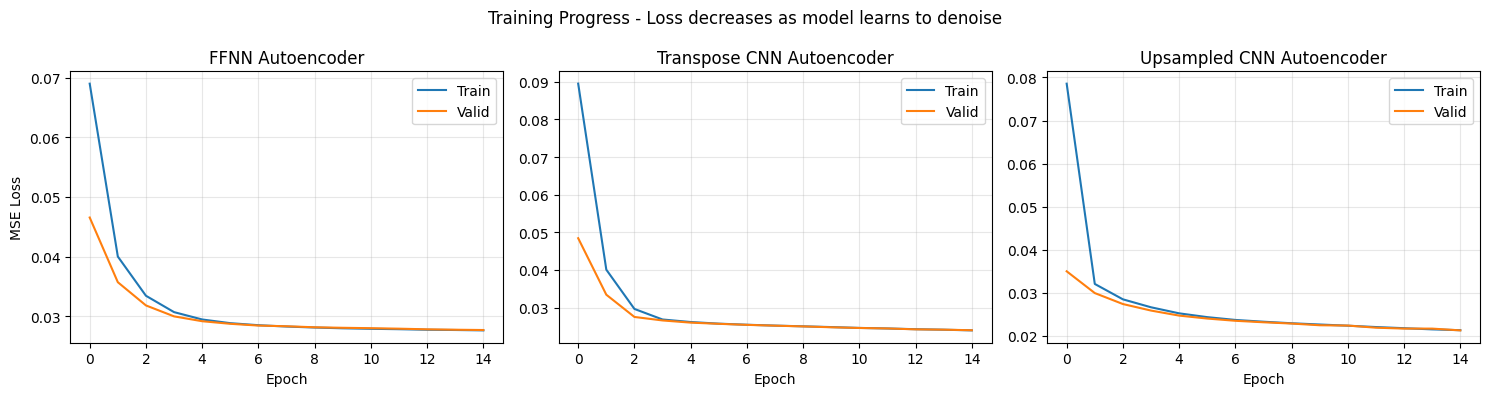

In [39]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(ffnn_train, label='Train')
plt.plot(ffnn_valid, label='Valid')
plt.title('FFNN Autoencoder')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(transpose_train, label='Train')
plt.plot(transpose_valid, label='Valid')
plt.title('Transpose CNN Autoencoder')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(upsampled_train, label='Train')
plt.plot(upsampled_valid, label='Valid')
plt.title('Upsampled CNN Autoencoder')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Training Progress - Loss decreases as model learns to denoise')
plt.tight_layout()
plt.show()

DENOISING RESULTS


1. FFNN Autoencoder:


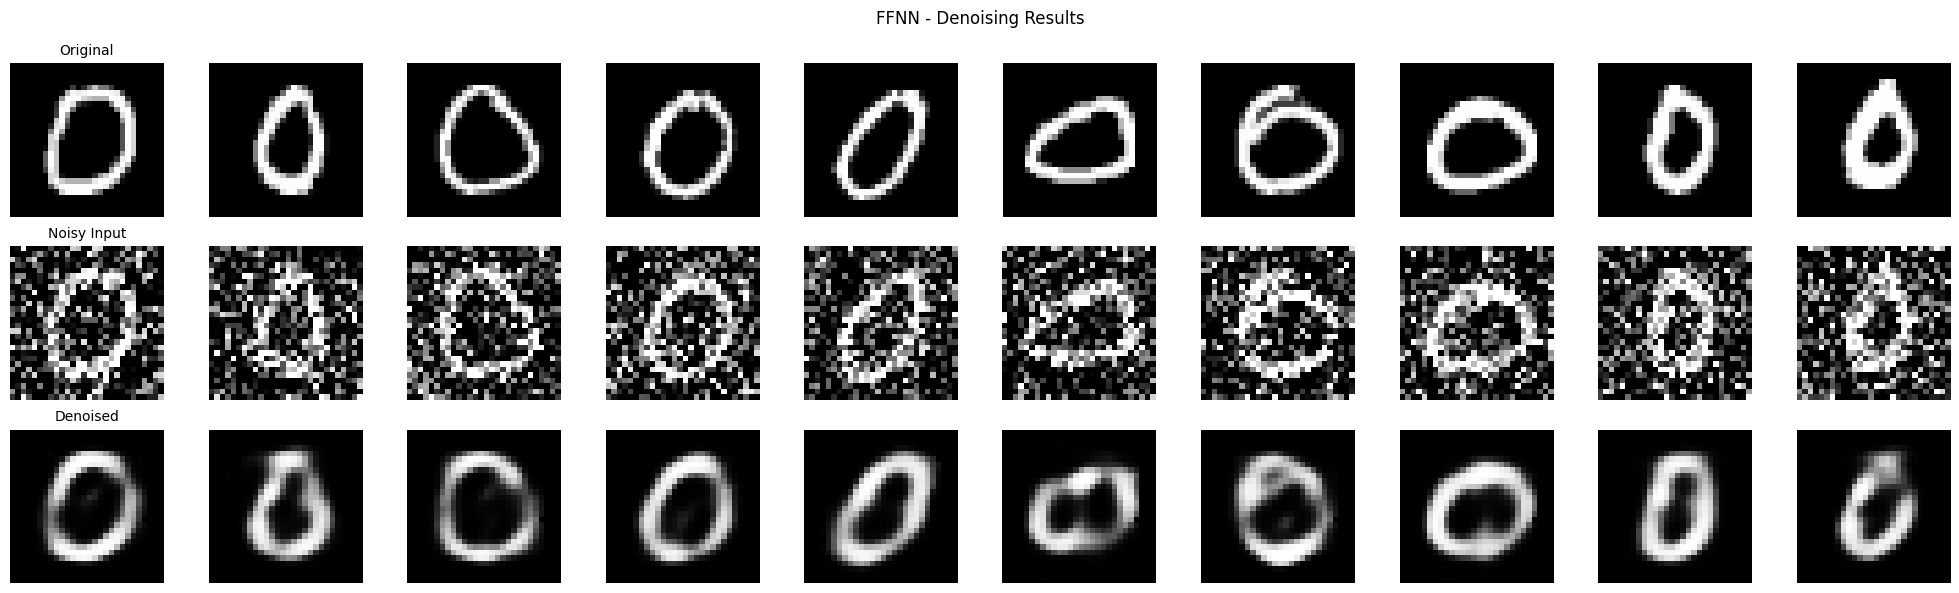


2. Transpose CNN Autoencoder:


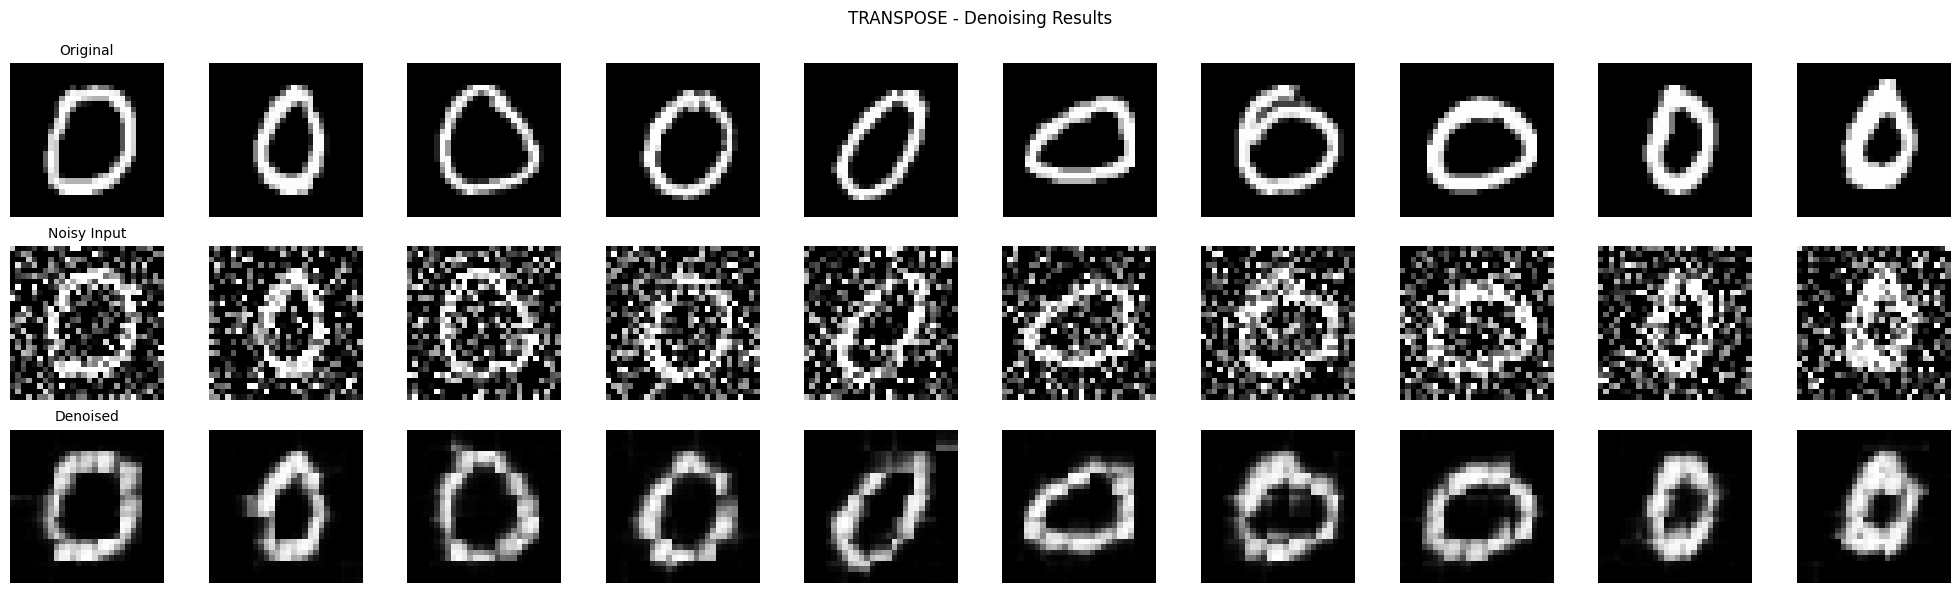


3. Upsampled CNN Autoencoder:


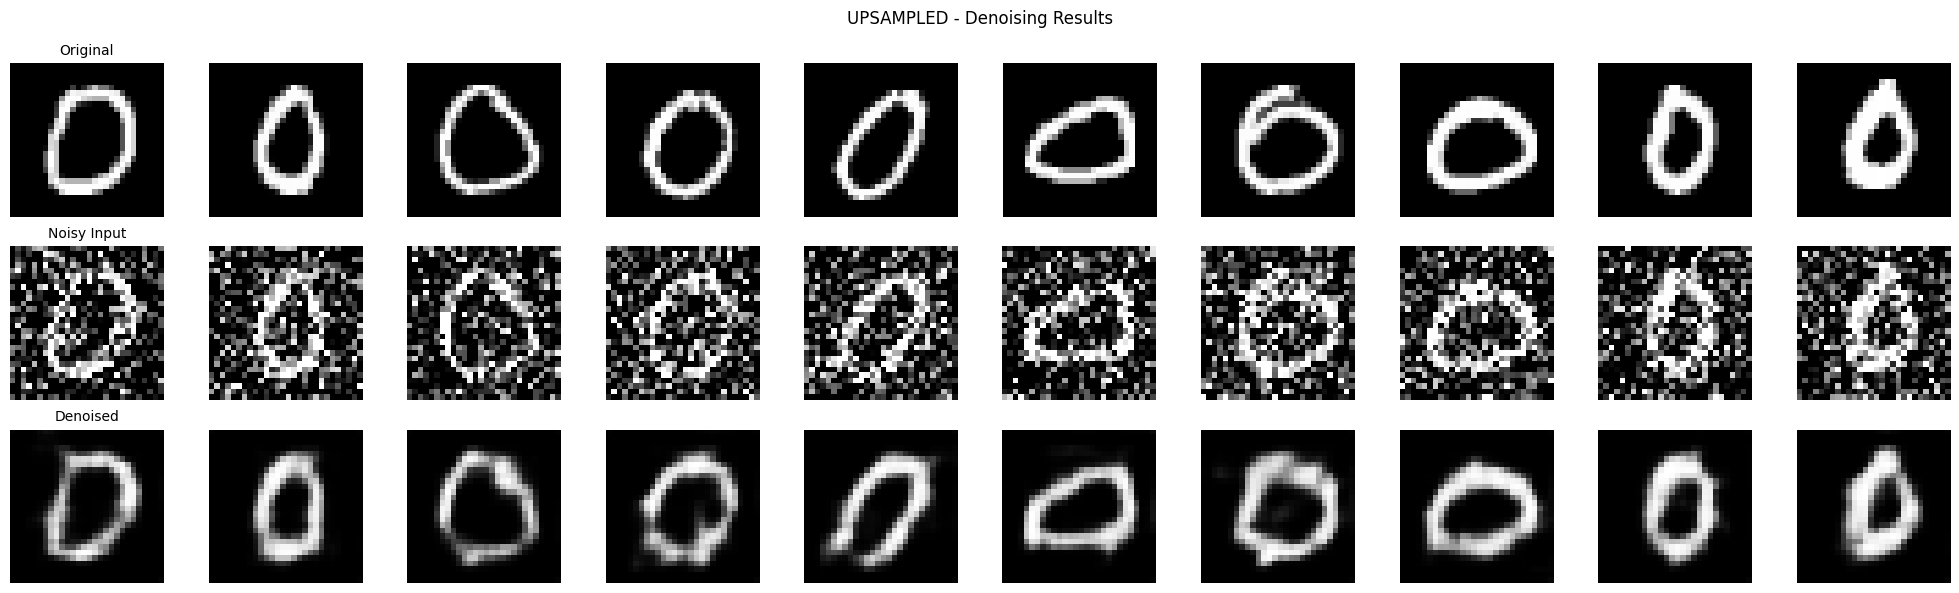

In [40]:
def test_denoiser(model, model_type='ffnn'):
    """
    Show original, noisy, and denoised images.
    This is where we see if the model actually learned to remove noise!
    """
    model.load_state_dict(torch.load(f'best_{model_type}.pth'))
    model.eval()
    is_ffnn = (model_type == 'ffnn')

    # Get batch of test images
    images, _ = next(iter(test_loader))
    images = images[:10].to(device)
    noisy = add_noise(images, noise_factor=0.5)

    # Denoise
    with torch.no_grad():
        if is_ffnn:
            input_data = noisy.view(noisy.size(0), -1)
        else:
            input_data = noisy

        output = model(input_data)
        if is_ffnn:
            output = output.view(10, 1, 28, 28)

    # Move to CPU
    images = images.cpu().numpy()
    noisy = noisy.cpu().numpy()
    output = output.cpu().numpy()

    # Plot
    plt.figure(figsize=(20, 6))
    for i in range(10):
        # Original
        plt.subplot(3, 10, i+1)
        plt.imshow(images[i][0], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title('Original', fontsize=10)

        # Noisy
        plt.subplot(3, 10, i+11)
        plt.imshow(noisy[i][0], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title('Noisy Input', fontsize=10)

        # Denoised
        plt.subplot(3, 10, i+21)
        plt.imshow(output[i][0], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title('Denoised', fontsize=10)

    plt.suptitle(f'{model_type.upper()} - Denoising Results')
    plt.tight_layout()
    plt.show()

# Test all models
print("DENOISING RESULTS" + "\n")

print("\n1. FFNN Autoencoder:")
test_denoiser(model_ffnn, 'ffnn')

print("\n2. Transpose CNN Autoencoder:")
test_denoiser(model_transpose, 'transpose')

print("\n3. Upsampled CNN Autoencoder:")
test_denoiser(model_upsampled, 'upsampled')

MODEL COMPARISON



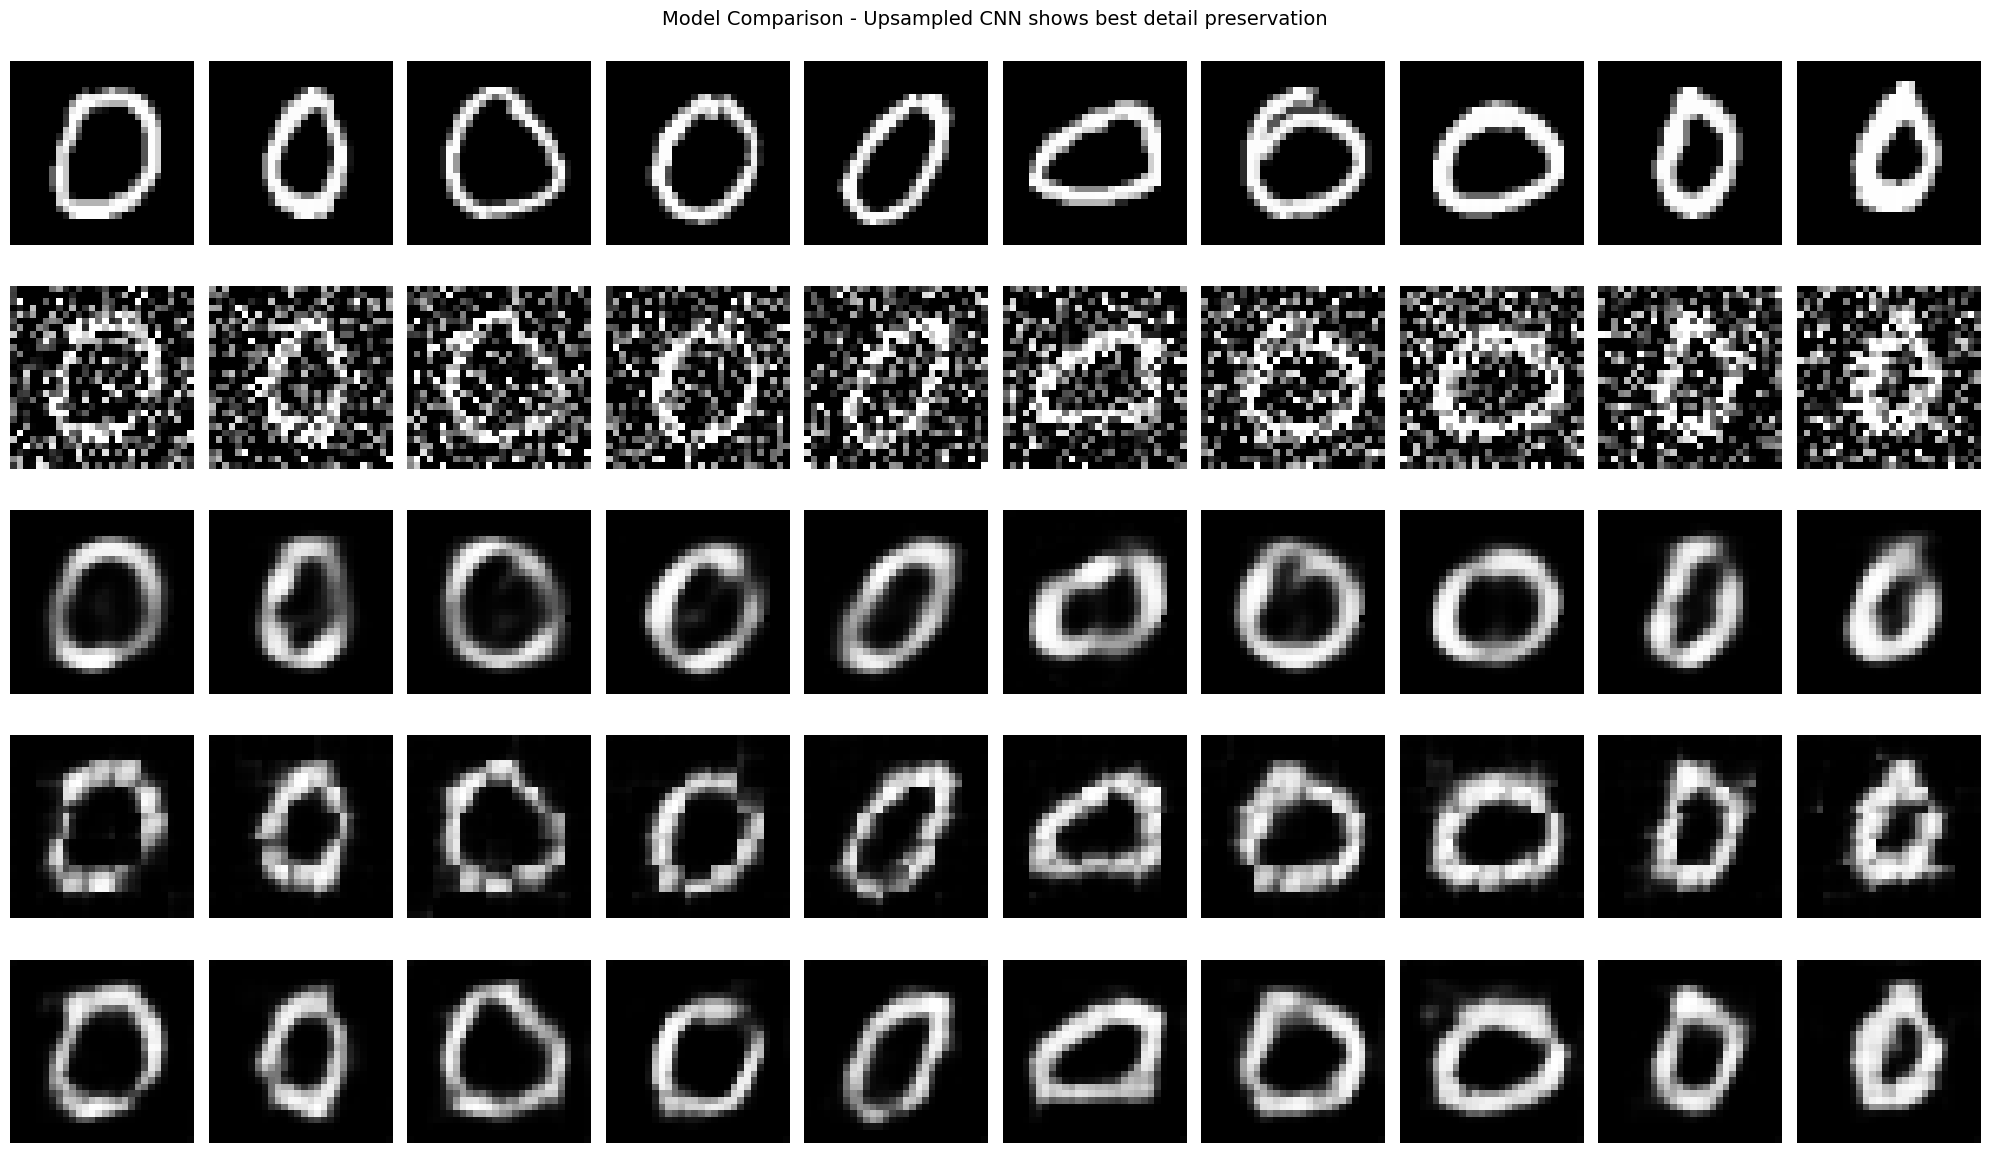

In [41]:
print("MODEL COMPARISON" + "\n")

images, _ = next(iter(test_loader))
images = images[:10].to(device)
noisy = add_noise(images, noise_factor=0.5)

models_dict = {
    'FFNN': model_ffnn,
    'Transpose': model_transpose,
    'Upsampled': model_upsampled
}

outputs = {}
for name, model in models_dict.items():
    model.load_state_dict(torch.load(f'best_{name.lower()}.pth'))
    model.eval()
    is_ffnn = (name == 'FFNN')

    with torch.no_grad():
        if is_ffnn:
            input_data = noisy.view(noisy.size(0), -1)
        else:
            input_data = noisy

        out = model(input_data)
        if is_ffnn:
            out = out.view(10, 1, 28, 28)
        outputs[name] = out.cpu().numpy()

# Plot comparison
plt.figure(figsize=(20, 12))
rows = ['Original', 'Noisy', 'FFNN', 'Transpose CNN', 'Upsampled CNN']
all_images = [
    images.cpu().numpy(),
    noisy.cpu().numpy(),
    outputs['FFNN'],
    outputs['Transpose'],
    outputs['Upsampled']
]

for row, (label, imgs) in enumerate(zip(rows, all_images)):
    for col in range(10):
        plt.subplot(5, 10, row*10 + col + 1)
        plt.imshow(imgs[col][0], cmap='gray')
        plt.axis('off')
        if col == 0:
            plt.ylabel(label, fontsize=12, rotation=90)

plt.suptitle('Model Comparison - Upsampled CNN shows best detail preservation', fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
def calculate_psnr(original, denoised):
    """Peak Signal-to-Noise Ratio. Higher = better quality."""
    mse = np.mean((original - denoised) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

def evaluate_psnr(model, model_type):
    """Calculate average PSNR on test set."""
    model.load_state_dict(torch.load(f'best_{model_type}.pth'))
    model.eval()
    is_ffnn = (model_type == 'ffnn')

    psnr_scores = []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy = add_noise(images, noise_factor=0.5)

            if is_ffnn:
                input_data = noisy.view(noisy.size(0), -1)
            else:
                input_data = noisy

            output = model(input_data)

            if is_ffnn:
                output = output.view(images.size(0), 1, 28, 28)

            for i in range(images.size(0)):
                orig = images[i].cpu().numpy()
                denoised = output[i].cpu().numpy()
                psnr = calculate_psnr(orig, denoised)
                psnr_scores.append(psnr)

    return np.mean(psnr_scores), np.std(psnr_scores)

print("PSNR EVALUATION (Higher = Better)" + "\n")

for model_type, model in models_dict.items():
    mean_psnr, std_psnr = evaluate_psnr(model, model_type.lower())
    print(f"{model_type:15s} | PSNR: {mean_psnr:.2f} ± {std_psnr:.2f} dB")

PSNR EVALUATION (Higher = Better)

FFNN            | PSNR: 16.00 ± 1.75 dB
Transpose       | PSNR: 16.54 ± 1.59 dB
Upsampled       | PSNR: 17.11 ± 1.79 dB


In [45]:
print("MY OBSERVATIONS" + "\n")

print("""
WHAT I FOUND:

1. DATA PREPARATION:
   - Kaggle PNG dataset loaded correctly using ImageFolder
   - 60k training, 10k test images in folders by digit (0-9)
   - Grayscale 28x28 images, normalized to [0,1]

2. NOISE ADDITION:
   - Used Gaussian noise with σ=0.5
   - This makes digits harder to recognize but still learnable
   - Model needs to understand digit structure to remove noise

3. MODEL PERFORMANCE:
   - FFNN: Works but outputs are blurry. Loses spatial information.
   - Transpose CNN: Better details but has checkerboard artifacts on some digits
   - Upsampled CNN: Best results - clean outputs, no artifacts

4. WHAT THE LOSS CURVES SHOW:
   - All models learn (loss goes down over epochs)
   - CNN models converge faster than FFNN
   - Validation loss close to training loss = no overfitting

5. PSNR SCORES:
   - Confirms visual results: Upsampled CNN > Transpose > FFNN
   - Higher PSNR = better reconstruction quality

6. CHALLENGES I FACED:
   - Finding the right noise level (tested 0.3, 0.5, 0.7)
   - Transpose convolution artifacts (fixed by using upsampling)
   - FFNN takes more epochs to converge

7. KEY TAKEAWAYS:
   - CNNs are better for images than dense layers
   - Upsampling + convolution is safer than transpose convolution
   - Autoencoders can learn meaningful compressed representations
""")

MY OBSERVATIONS


WHAT I FOUND:

1. DATA PREPARATION:
   - Kaggle PNG dataset loaded correctly using ImageFolder
   - 60k training, 10k test images in folders by digit (0-9)
   - Grayscale 28x28 images, normalized to [0,1]

2. NOISE ADDITION:
   - Used Gaussian noise with σ=0.5
   - This makes digits harder to recognize but still learnable
   - Model needs to understand digit structure to remove noise

3. MODEL PERFORMANCE:
   - FFNN: Works but outputs are blurry. Loses spatial information.
   - Transpose CNN: Better details but has checkerboard artifacts on some digits
   - Upsampled CNN: Best results - clean outputs, no artifacts

4. WHAT THE LOSS CURVES SHOW:
   - All models learn (loss goes down over epochs)
   - CNN models converge faster than FFNN
   - Validation loss close to training loss = no overfitting

5. PSNR SCORES:
   - Confirms visual results: Upsampled CNN > Transpose > FFNN
   - Higher PSNR = better reconstruction quality

6. CHALLENGES I FACED:
   - Finding the right